c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


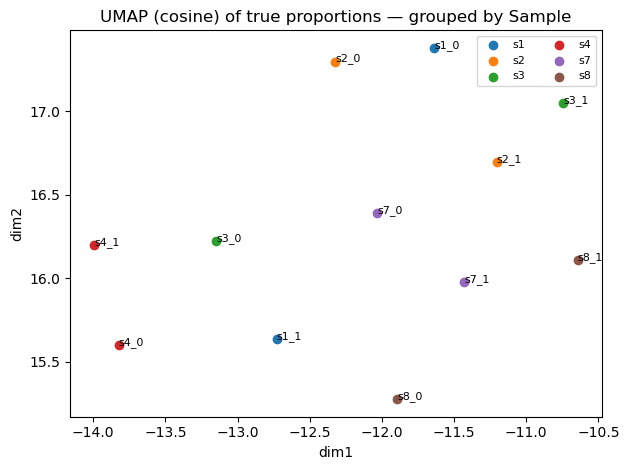

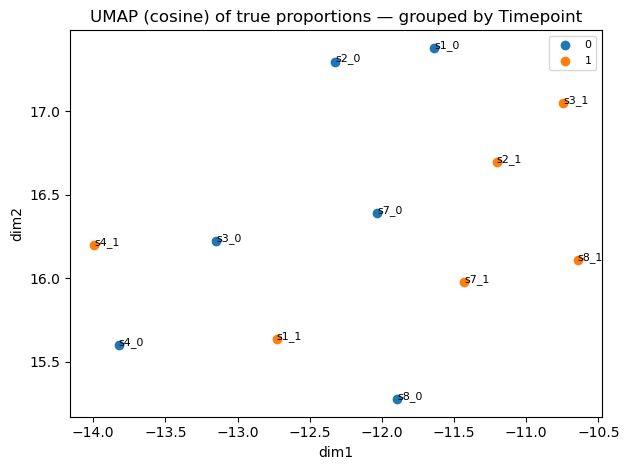

In [9]:
# Jupyter cell: UMAP of train_bulk_trueprops (with proper integer indexing for groups)
TRUEPROPS_CSV = r"../train_data/train_bulk_trueprops.csv"  # <-- 改成你的實際路徑

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_sample(col: str):
    s = str(col).strip()
    m = re.match(r"^(s\d+)[_\-]?([A-Za-z0-9]+)$", s, flags=re.IGNORECASE)
    if m: return m.group(1).lower(), m.group(2).lower()
    parts = s.split("_", 1)
    return (parts[0].lower(), parts[1].lower()) if len(parts)==2 else (s.lower(), "")

def embed_2d(X: np.ndarray, random_state: int = 42):
    # Prefer UMAP; fallback to t-SNE -> PCA
    try:
        import umap
        reducer = umap.UMAP(n_neighbors=min(15, max(2, X.shape[0]//2)),
                            min_dist=0.1, metric="cosine",
                            random_state=random_state)
        Y = reducer.fit_transform(X)
        return Y, "UMAP (cosine)"
    except Exception:
        try:
            from sklearn.manifold import TSNE
            Y = TSNE(n_components=2, perplexity=min(30, max(5, X.shape[0]//3)),
                     learning_rate="auto", init="pca",
                     random_state=random_state).fit_transform(X)
            return Y, "t-SNE"
        except Exception:
            from sklearn.decomposition import PCA
            Y = PCA(n_components=2, random_state=random_state).fit_transform(X)
            return Y, "PCA"

# 1) Load (rows=cell types, cols=samples) -> transpose to samples x celltypes
df = pd.read_csv(TRUEPROPS_CSV, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
X = df.T.copy()
samples = X.index.tolist()

# meta
meta = pd.DataFrame(index=samples)
meta[["Sample","Timepoint"]] = [parse_sample(c) for c in samples]

# 2) Embedding
Y, tag = embed_2d(X.values, random_state=42)  # Y.shape[0] == len(samples)

# 3) Plot by Sample  (FIX: label index -> integer positions)
plt.figure()
for grp, idx_labels in meta.groupby("Sample").groups.items():
    pos = meta.index.get_indexer(list(idx_labels))  # <- 轉成整數位置
    plt.scatter(Y[pos, 0], Y[pos, 1], label=grp)
for i, name in enumerate(samples):
    plt.text(Y[i, 0], Y[i, 1], name, fontsize=8)
plt.xlabel("dim1"); plt.ylabel("dim2")
plt.title(f"{tag} of true proportions — grouped by Sample")
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# 4) Plot by Timepoint (同樣用整數位置)
plt.figure()
for grp, idx_labels in meta.groupby("Timepoint").groups.items():
    pos = meta.index.get_indexer(list(idx_labels))
    plt.scatter(Y[pos, 0], Y[pos, 1], label=str(grp))
for i, name in enumerate(samples):
    plt.text(Y[i, 0], Y[i, 1], name, fontsize=8)
plt.xlabel("dim1"); plt.ylabel("dim2")
plt.title(f"{tag} of true proportions — grouped by Timepoint")
plt.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()


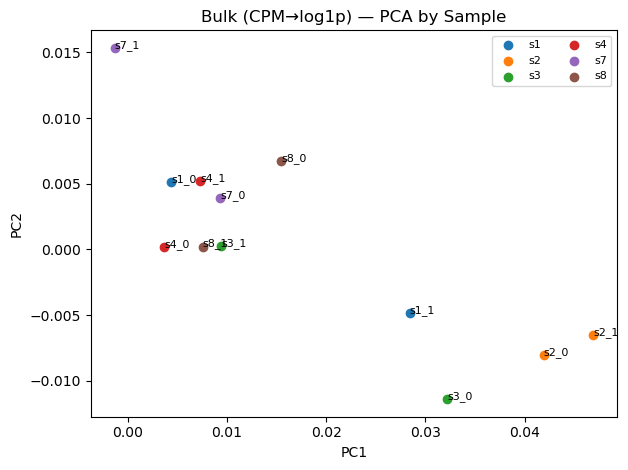

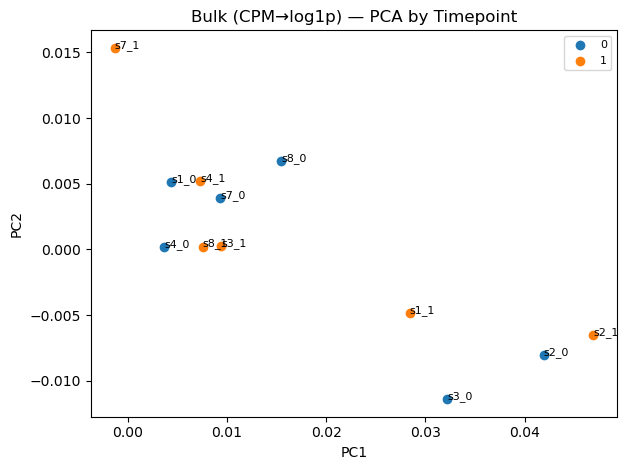

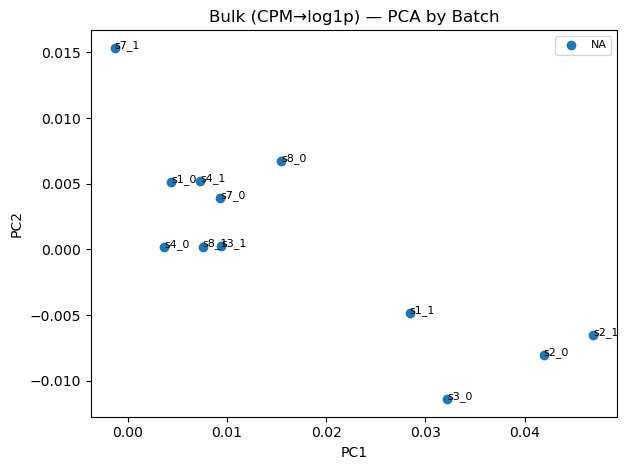

In [11]:
# Jupyter cell: Inspect batch effect in train_bulk.csv (no correction, just plots)
BULK_PATH  = r"../train_data/train_bulk.csv"

# 如果你有 bulk 的批次資訊，填在這裡；沒有就留空字典（只看 Sample/Timepoint）
# 例：{"s1_0":"B1","s1_1":"B1","s2_0":"B2","s2_1":"B2", ...}
BATCH_MAP = {}

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_sample(col: str):
    s = str(col).strip().lower()
    m = re.match(r"^(s\d+)[_\-]?([A-Za-z0-9]+)$", s)
    if m: return m.group(1), m.group(2)
    parts = s.split("_",1)
    return (parts[0], parts[1]) if len(parts)==2 else (s, "")

def cpm_log1p(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def pca_2d(X: np.ndarray):
    Xc = X - X.mean(axis=0, keepdims=True)
    U,S,Vt = np.linalg.svd(Xc, full_matrices=False)
    return Vt[:2].T  # (samples x 2)

# 1) Load bulk
bulk = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
B = cpm_log1p(bulk)            # 標準化，與單細胞流程一致
X = B.T.values                 # samples x genes
samples = list(B.columns)

# 2) Meta: Sample, Timepoint, Batch(可選)
meta = pd.DataFrame(index=samples)
meta[["Sample","Timepoint"]] = [parse_sample(c) for c in samples]
meta["Batch"] = [BATCH_MAP.get(s, "NA") for s in samples]

# 3) PCA
Y = pca_2d(X)

# 4) Plot by Sample（看每個 sN 的 0/1 是否彼此靠近）
plt.figure()
for grp, idx in meta.groupby("Sample").groups.items():
    pos = meta.index.get_indexer(list(idx))
    plt.scatter(Y[pos,0], Y[pos,1], label=grp)
for i, name in enumerate(samples):
    plt.text(Y[i,0], Y[i,1], name, fontsize=8)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Bulk (CPM→log1p) — PCA by Sample")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

# 5) Plot by Timepoint（0/1 是否形成兩群，屬生物效應而非批次）
plt.figure()
for grp, idx in meta.groupby("Timepoint").groups.items():
    pos = meta.index.get_indexer(list(idx))
    plt.scatter(Y[pos,0], Y[pos,1], label=str(grp))
for i, name in enumerate(samples):
    plt.text(Y[i,0], Y[i,1], name, fontsize=8)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Bulk (CPM→log1p) — PCA by Timepoint")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

# 6) Plot by Batch（若沒提供批次則都顯示 NA）
plt.figure()
for grp, idx in meta.groupby("Batch").groups.items():
    pos = meta.index.get_indexer(list(idx))
    plt.scatter(Y[pos,0], Y[pos,1], label=str(grp))
for i, name in enumerate(samples):
    plt.text(Y[i,0], Y[i,1], name, fontsize=8)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Bulk (CPM→log1p) — PCA by Batch")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\scanpy\preprocessing\_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


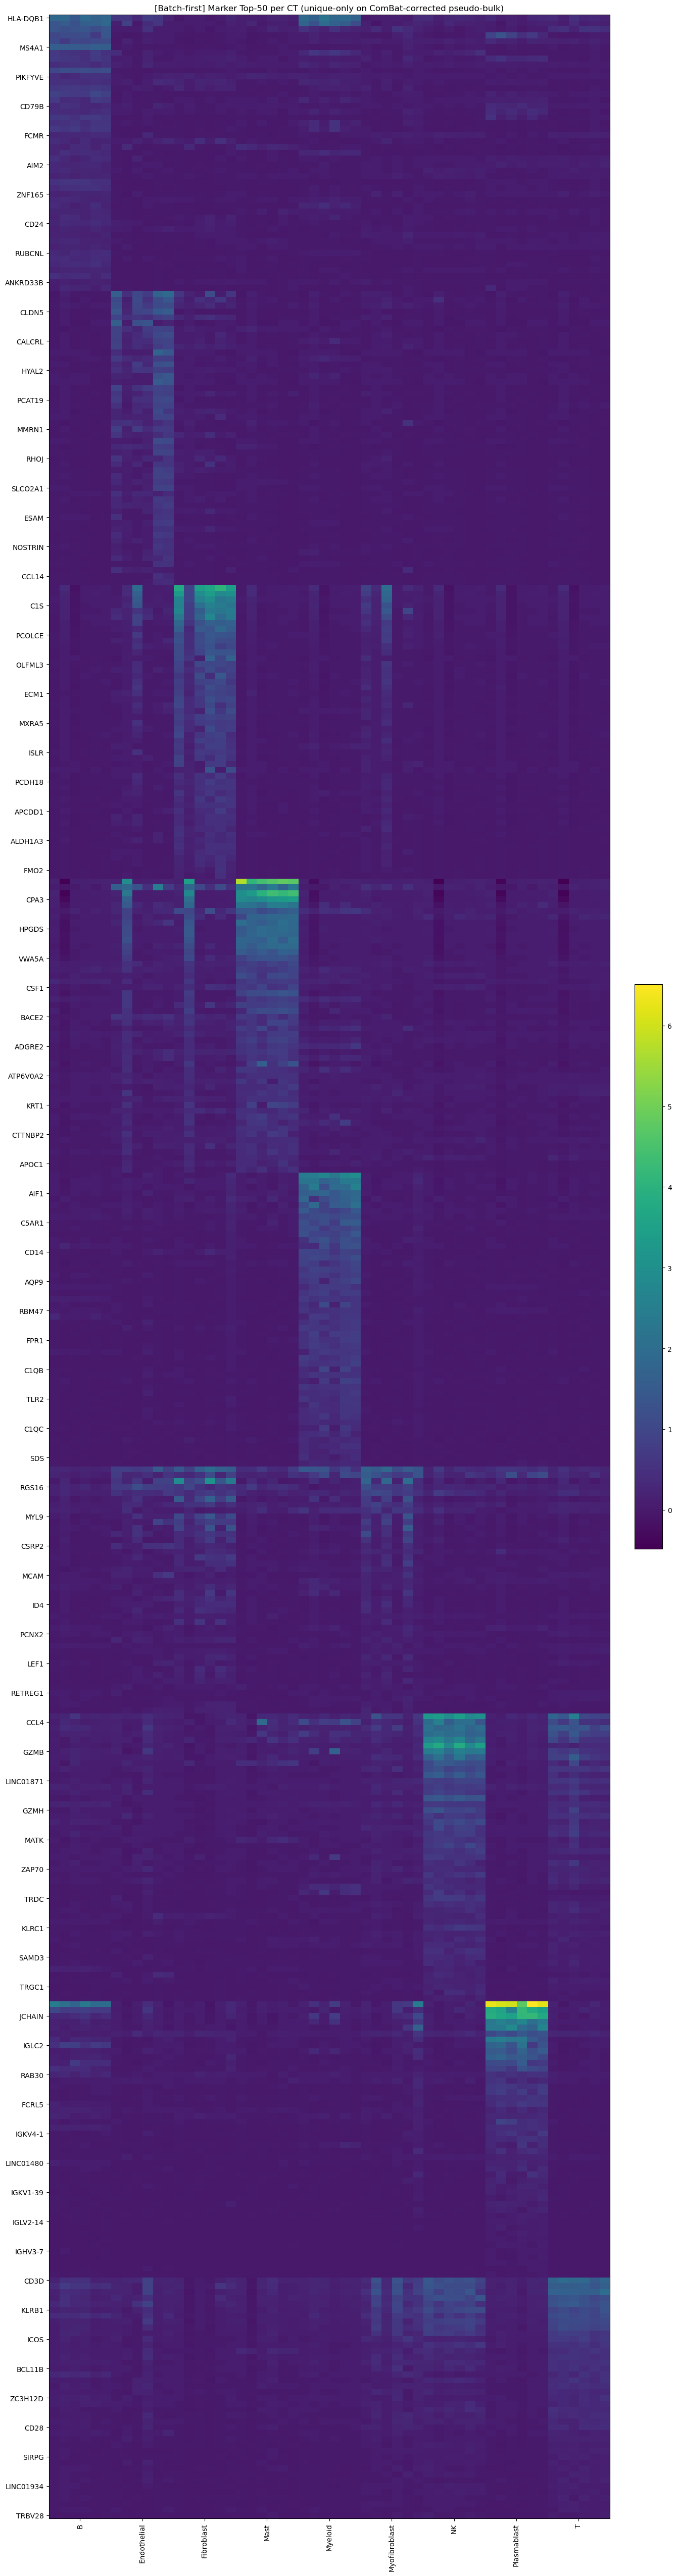

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 12 genes
  - B: kept 47 genes
  - Endothelial: kept 50 genes
  - Fibroblast: kept 50 genes
  - Mast: kept 50 genes
  - Myeloid: kept 50 genes
  - Myofibroblast: kept 42 genes
  - NK: kept 49 genes
  - Plasmablast: kept 47 genes
  - T: kept 41 genes
[Total rows plotted] 426


In [ ]:
# Jupyter cell: Batch-first marker selection (on ComBat-corrected pseudo-bulk) → unique-only Top-50/CT → one big heatmap
AD_PATH       = r"../train_data/train_adata.h5ad"
CELLTYPE_COL  = "highLevelType"   # fallback: 'cell_type'
SAMPLE_COL    = "Sample"
TOP_K         = 50
USE_COMBAT    = True              # 先校正再選 marker：True 開啟 ComBat (batch=Sample)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- helpers ----------------
def _need_scanpy():
    import scanpy as sc
    return sc

def _preprocess(adata):
    sc = _need_scanpy()
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

def _pseudobulk_sample_ct(adata, ct_col: str, sample_col: str) -> pd.DataFrame:
    # genes × (sample|ct)
    obs = adata.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        X = adata.X[idx]
        cols.append(np.asarray(X.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=adata.var_names.astype(str), columns=names)

def _combat(pb: pd.DataFrame) -> pd.DataFrame:
    # ComBat on pseudo-bulk (batch = Sample)
    sc = _need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def _contrast_topk(pb: pd.DataFrame, top_k: int) -> dict:
    """
    用已 batch-correct 的 pseudo-bulk 計對比分數：
      score(g, ct) = log2( mean_pb[g, ct] / mean_pb[g, rest] )
    取每個 CT 的 Top-K 基因；回傳 {ct: [genes...]}
    """
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    mean_all = pb.mean(axis=1) + 1e-9
    out = {}
    for ct in cts:
        cols_ct = [c for c in pb.columns if c.split("|",1)[1] == ct]
        if not cols_ct:
            out[ct] = []
            continue
        m_ct = pb[cols_ct].mean(axis=1)
        # rest = 加權方式：其他 CT 的均值（避免除以 0）
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9))
        out[ct] = list(score.sort_values(ascending=False).index[:top_k])
    return out

def _row_zscore(M: np.ndarray) -> np.ndarray:
    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1.0
    return (M - mu) / sd

# ---------------- pipeline ----------------
sc = _need_scanpy()
adata = sc.read_h5ad(AD_PATH)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("Missing cell-type column (highLevelType/cell_type).")
if SAMPLE_COL not in adata.obs:
    raise KeyError("Missing 'Sample' column in adata.obs.")

_preprocess(adata)

# 1) pseudo-bulk
pb = _pseudobulk_sample_ct(adata, CELLTYPE_COL, SAMPLE_COL)

# 2) 先做 batch 校正（Sample 為 batch）
if USE_COMBAT:
    pb = _combat(pb)

# 3) 在校正後的 pseudo-bulk 上選 marker（CT vs rest, logFC Top-K/CT）
ct_to_top = _contrast_topk(pb, TOP_K)

# 4) 移除出現在 ≥2 個 CT Top-K 名單的基因（unique-only 規則）
from collections import Counter
gene_counts = Counter(g for genes in ct_to_top.values() for g in genes)
dup_genes = {g for g, n in gene_counts.items() if n >= 2}
ct_to_unique = {ct: [g for g in genes if g not in dup_genes] for ct, genes in ct_to_top.items()}

# 5) 欄排序（按 CT 分組），列排序（各 CT 的 unique genes 依全欄平均降冪，串接）
cts = sorted({c.split("|",1)[1] for c in pb.columns})
ct_to_cols = {ct: [c for c in pb.columns if c.split("|",1)[1] == ct] for ct in cts}
row_global_mean = pb.mean(axis=1)

row_order_concat = []
ct_sizes_kept = {}
for ct in cts:
    uniq = [g for g in ct_to_unique.get(ct, []) if g in pb.index]
    uniq_sorted = sorted(uniq, key=lambda g: row_global_mean.loc[g], reverse=True)
    if uniq_sorted:
        row_order_concat.extend(uniq_sorted)
    ct_sizes_kept[ct] = len(uniq_sorted)

if len(row_order_concat) == 0:
    raise ValueError("No genes remain after duplicate-removal; lower TOP_K or allow duplicates.")

ordered_cols, group_ticks, group_labels = [], [], []
pos = 0
for ct in cts:
    cols_ct = ct_to_cols[ct]
    if not cols_ct: continue
    ordered_cols.extend(cols_ct)
    group_ticks.append(pos + (len(cols_ct)-1)/2)
    group_labels.append(ct)
    pos += len(cols_ct)

M = pb.loc[row_order_concat, ordered_cols]
Z = _row_zscore(M.values)

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(Z, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


In [1]:
# file: scripts/markers_fast_robust.py
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

EPS = 1e-9

# ---------------- weights: 每個 Sample|CT 的 cell 數 ----------------
def make_weights_from_adata(adata, sample_col: str, ct_col: str) -> pd.Series:
    key = adata.obs[sample_col].astype(str) + "|" + adata.obs[ct_col].astype(str)
    cnt = key.value_counts()
    return cnt  # index: "Sample|CT"

# ---------------- 加權 Cohen's d（向量化，超快） ----------------
def weighted_cohens_d(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    """
    X: (n_samples, n_genes), y: {0,1}, w: sample_weight >=0
    回傳 d 向量（每個基因一個值）；只用樣本層級統計，考慮不平衡。
    """
    w = np.asarray(w, float)
    X = np.asarray(X, float)
    y = np.asarray(y, int)

    w1 = w * (y == 1)
    w0 = w * (y == 0)
    s1 = w1.sum() + EPS
    s0 = w0.sum() + EPS

    # 加權均值
    mu1 = (w1[:, None] * X).sum(0) / s1
    mu0 = (w0[:, None] * X).sum(0) / s0

    # 加權變異（unbiased-ish）
    v1 = (w1[:, None] * (X - mu1) ** 2).sum(0) / s1
    v0 = (w0[:, None] * (X - mu0) ** 2).sum(0) / s0

    # 合併標準差（Hedges g 簡化）
    sp = np.sqrt((v1 + v0) / 2.0 + EPS)
    d = (mu1 - mu0) / sp
    return d

# ---------------- 主流程：超快穩健 marker 選擇 ----------------
def fast_robust_markers(
    pb: pd.DataFrame,
    top_k: int,
    weights: Optional[pd.Series] = None,
    use_standardize: bool = True,
    C: float = 1.0,
    l1_ratio: Optional[float] = None,  # None → pure L1；可設 0.5 做 elastic net
    random_state: int = 42
) -> Dict[str, List[str]]:
    """
    免調參、考慮不平衡的快速 marker 選擇：
    - 加權 Cohen's d（CT vs REST，向量化）
    - L1-Logistic(saga) + class_weight='balanced'（樣本權重與類別權重同時考慮）
    - 分數融合：rank(d正向) 與 rank(coef正向) 的平均

    回傳 {ct: topK 基因list}
    """
    # 權重向量
    if weights is None:
        weights = pd.Series(1.0, index=pb.columns, dtype=float)
    else:
        weights = weights.reindex(pb.columns).fillna(0.0).astype(float)

    X = pb.T.to_numpy(dtype=float)  # (n_samples, n_genes)
    genes = pb.index.to_numpy(str)
    col_ct = np.array([c.split("|", 1)[1] for c in pb.columns], dtype=object)
    cts = sorted(set(col_ct))

    # 標準化（Logistic 對尺度敏感；同時讓係數可比）
    scaler = StandardScaler(with_mean=True, with_std=True) if use_standardize else None
    Xz = scaler.fit_transform(X) if scaler is not None else X

    out: Dict[str, List[str]] = {}
    for ct in cts:
        y = (col_ct == ct).astype(int)
        sw = weights.values.astype(float)

        # 1) 加權 Cohen's d
        d = weighted_cohens_d(Xz, y, sw)  # 向量化

        # 2) L1 / Elastic-net Logistic（平衡類別 + 樣本權重）
        if l1_ratio is None:
            clf = LogisticRegression(
                penalty="l1", solver="saga", C=C, max_iter=2000, n_jobs=-1,
                class_weight="balanced", random_state=random_state
            )
        else:
            clf = LogisticRegression(
                penalty="elasticnet", l1_ratio=l1_ratio, solver="saga",
                C=C, max_iter=2000, n_jobs=-1, class_weight="balanced",
                random_state=random_state
            )
        clf.fit(Xz, y, sample_weight=sw)
        coef = clf.coef_.ravel()  # 正類方向

        # 3) 只取「上調」：d>0 且 coef>0
        pos = (d > 0) & (coef > 0)
        if not np.any(pos):
            # 若沒正向基因，退化為 d 排序
            order = np.argsort(-d)
            out[ct] = [g for g in genes[order][:top_k]]
            continue

        # 4) 分數融合（秩標準化避免尺度問題）
        def ranknorm(v):
            r = v.argsort().argsort().astype(float)  # 0..n-1
            return (r + 1.0) / (len(r) + 1.0)

        s = np.zeros_like(d)
        s[pos] = 0.5 * ranknorm(d[pos]) + 0.5 * ranknorm(coef[pos])

        order = np.argsort(-s)
        sel = order[:top_k]
        out[ct] = genes[sel].tolist()

    return out

# ---------------- Heatmap：CT 加權平均 → row z-score ----------------
def build_marker_heatmap_matrix(
    pb: pd.DataFrame,
    markers_by_ct: Dict[str, List[str]],
    weights: Optional[pd.Series] = None
) -> Tuple[np.ndarray, List[str], List[str]]:
    col_ct = pd.Index([c.split("|", 1)[1] for c in pb.columns], name="CT")
    cts = sorted(set(col_ct))
    if weights is None:
        weights = pd.Series(1.0, index=pb.columns, dtype=float)
    else:
        weights = weights.reindex(pb.columns).fillna(0.0).astype(float)

    row_genes: List[str] = []
    for ct in markers_by_ct:
        for g in markers_by_ct[ct]:
            if g not in row_genes and g in pb.index:
                row_genes.append(g)
    if not row_genes:
        raise ValueError("No markers found in pb.")

    sub = pb.loc[row_genes]
    M = np.zeros((len(row_genes), len(cts)), float)
    for j, ct in enumerate(cts):
        cols = [col for col, cc in zip(pb.columns, col_ct) if cc == ct]
        if not cols: continue
        w = weights.loc[cols].to_numpy(float)
        X = sub[cols].to_numpy(float)
        M[:, j] = (X @ w) / (w.sum() + EPS)

    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd = np.where(sd < 1e-9, 1.0, sd)
    Mz = (M - mu) / sd
    return Mz, row_genes, cts

def plot_marker_heatmap(M: np.ndarray, row_genes: List[str], col_cts: List[str], title: str):
    fig, ax = plt.subplots(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.14*M.shape[0])))
    im = ax.imshow(M, aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(col_cts))); ax.set_xticklabels(col_cts, rotation=45, ha="right")
    ax.set_yticks(range(len(row_genes)))
    if len(row_genes) <= 80:
        ax.set_yticklabels(row_genes, fontsize=8)
    else:
        step = max(1, len(row_genes)//80)
        ax.set_yticks(range(0, len(row_genes), step))
        ax.set_yticklabels([row_genes[i] for i in range(0, len(row_genes), step)], fontsize=7)
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("row z-score")
    plt.tight_layout(); plt.show()


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\scanpy\preprocessing\_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


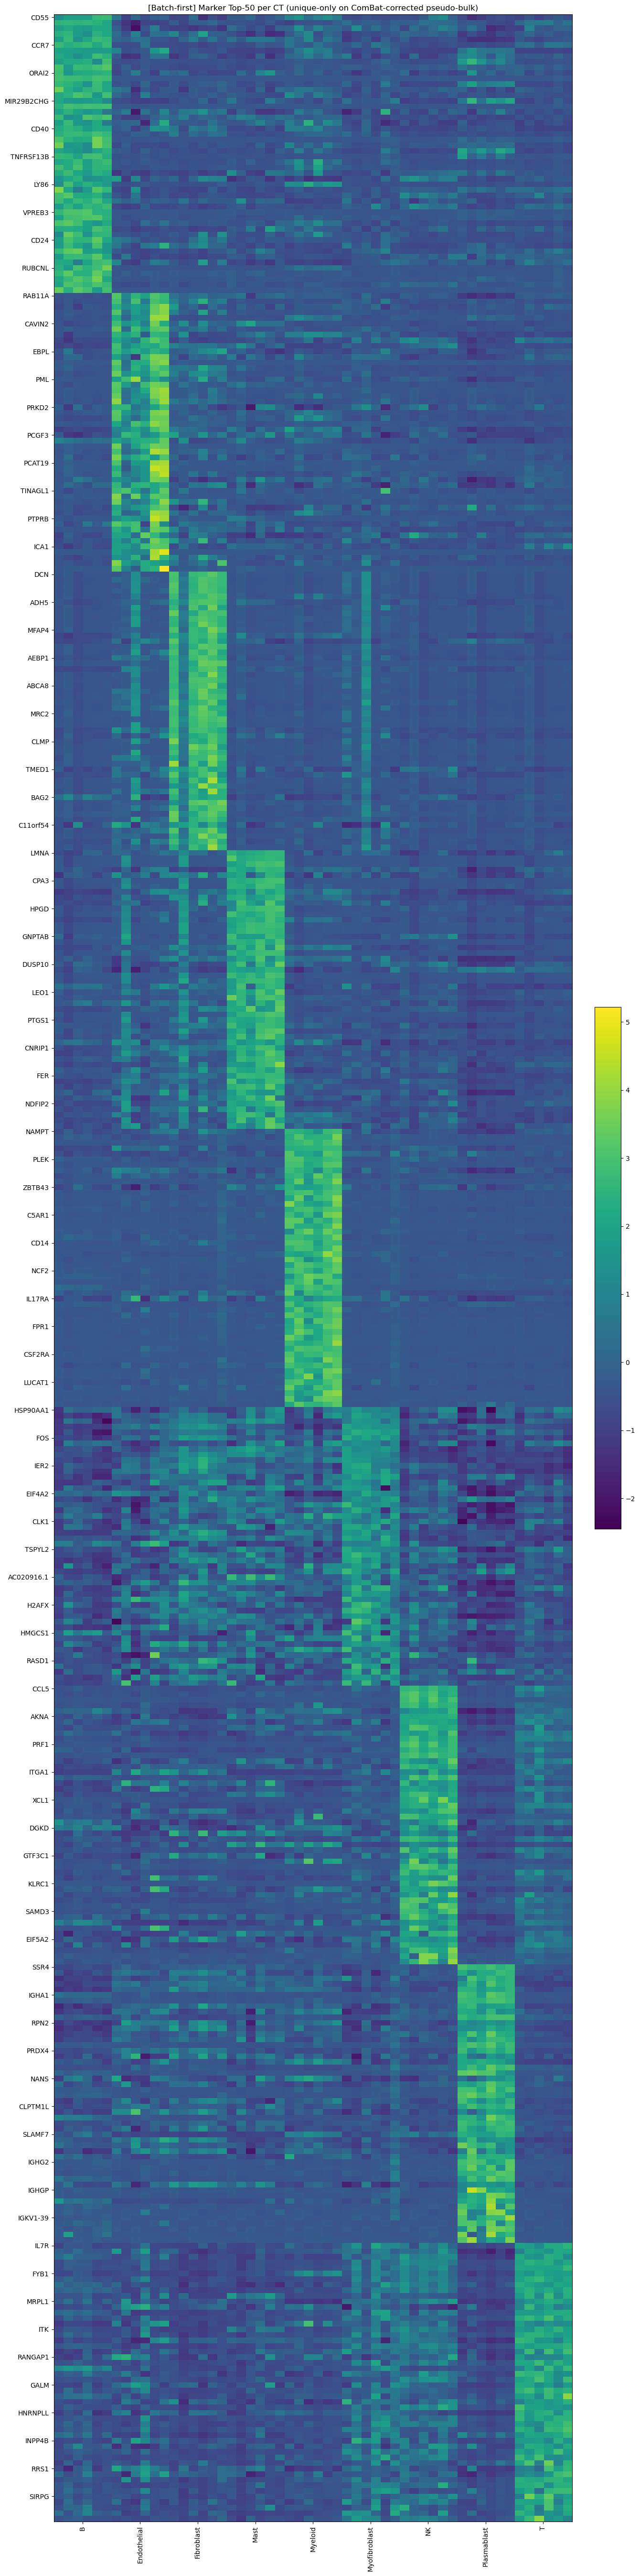

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 0 genes
  - B: kept 50 genes
  - Endothelial: kept 50 genes
  - Fibroblast: kept 50 genes
  - Mast: kept 50 genes
  - Myeloid: kept 50 genes
  - Myofibroblast: kept 50 genes
  - NK: kept 50 genes
  - Plasmablast: kept 50 genes
  - T: kept 50 genes
[Total rows plotted] 450


In [ ]:
# Jupyter cell: Batch-first marker selection (on ComBat-corrected pseudo-bulk) → unique-only Top-50/CT → one big heatmap
AD_PATH       = r"../train_data/train_adata.h5ad"
CELLTYPE_COL  = "highLevelType"   # fallback: 'cell_type'
SAMPLE_COL    = "Sample"
TOP_K         = 50
USE_COMBAT    = True              # 先校正再選 marker：True 開啟 ComBat (batch=Sample)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- helpers ----------------
def _need_scanpy():
    import scanpy as sc
    return sc

def _preprocess(adata):
    sc = _need_scanpy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

def _pseudobulk_sample_ct(adata, ct_col: str, sample_col: str) -> pd.DataFrame:
    # genes × (sample|ct)
    obs = adata.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        X = adata.X[idx]
        cols.append(np.asarray(X.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=adata.var_names.astype(str), columns=names)

def _combat(pb: pd.DataFrame) -> pd.DataFrame:
    # ComBat on pseudo-bulk (batch = Sample)
    sc = _need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def _contrast_topk(pb: pd.DataFrame, top_k: int) -> dict:
    """
    用已 batch-correct 的 pseudo-bulk 計對比分數：
      score(g, ct) = log2( mean_pb[g, ct] / mean_pb[g, rest] )
    取每個 CT 的 Top-K 基因；回傳 {ct: [genes...]}
    """
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    mean_all = pb.mean(axis=1) + 1e-9
    out = {}
    for ct in cts:
        cols_ct = [c for c in pb.columns if c.split("|",1)[1] == ct]
        if not cols_ct:
            out[ct] = []
            continue
        m_ct = pb[cols_ct].mean(axis=1)
        # rest = 加權方式：其他 CT 的均值（避免除以 0）
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9))
        out[ct] = list(score.sort_values(ascending=False).index[:top_k])
    return out

def _row_zscore(M: np.ndarray) -> np.ndarray:
    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1.0
    return (M - mu) / sd

# ---------------- pipeline ----------------
sc = _need_scanpy()
adata = sc.read_h5ad(AD_PATH)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("Missing cell-type column (highLevelType/cell_type).")
if SAMPLE_COL not in adata.obs:
    raise KeyError("Missing 'Sample' column in adata.obs.")

_preprocess(adata)

# 1) pseudo-bulk
pb = _pseudobulk_sample_ct(adata, CELLTYPE_COL, SAMPLE_COL)

# 2) 先做 batch 校正（Sample 為 batch）
if USE_COMBAT:
    pb = _combat(pb)

# 3) 在校正後的 pseudo-bulk 上選 marker（CT vs rest, logFC Top-K/CT）
weights = make_weights_from_adata(adata, sample_col=SAMPLE_COL, ct_col=CELLTYPE_COL)
ct_to_top = fast_robust_markers(
    pb=pb,
    top_k=TOP_K,
    weights=weights,          # 考慮不平衡
    use_standardize=True,     # 建議 True
    C=1.0,                    # 不調參也很穩；要更稀疏可降 C 或設 l1_ratio=0.5
    l1_ratio=None,            # None=純 L1；可改 0.5 為 elastic-net
    random_state=42
)
# 4) 移除出現在 ≥2 個 CT Top-K 名單的基因（unique-only 規則）
from collections import Counter
gene_counts = Counter(g for genes in ct_to_top.values() for g in genes)
dup_genes = {g for g, n in gene_counts.items() if n >= 2}
ct_to_unique = {ct: [g for g in genes if g not in dup_genes] for ct, genes in ct_to_top.items()}

# 5) 欄排序（按 CT 分組），列排序（各 CT 的 unique genes 依全欄平均降冪，串接）
cts = sorted({c.split("|",1)[1] for c in pb.columns})
ct_to_cols = {ct: [c for c in pb.columns if c.split("|",1)[1] == ct] for ct in cts}
row_global_mean = pb.mean(axis=1)

row_order_concat = []
ct_sizes_kept = {}
for ct in cts:
    uniq = [g for g in ct_to_unique.get(ct, []) if g in pb.index]
    uniq_sorted = sorted(uniq, key=lambda g: row_global_mean.loc[g], reverse=True)
    if uniq_sorted:
        row_order_concat.extend(uniq_sorted)
    ct_sizes_kept[ct] = len(uniq_sorted)

if len(row_order_concat) == 0:
    raise ValueError("No genes remain after duplicate-removal; lower TOP_K or allow duplicates.")

ordered_cols, group_ticks, group_labels = [], [], []
pos = 0
for ct in cts:
    cols_ct = ct_to_cols[ct]
    if not cols_ct: continue
    ordered_cols.extend(cols_ct)
    group_ticks.append(pos + (len(cols_ct)-1)/2)
    group_labels.append(ct)
    pos += len(cols_ct)

M = pb.loc[row_order_concat, ordered_cols]
Z = _row_zscore(M.values)

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(Z, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


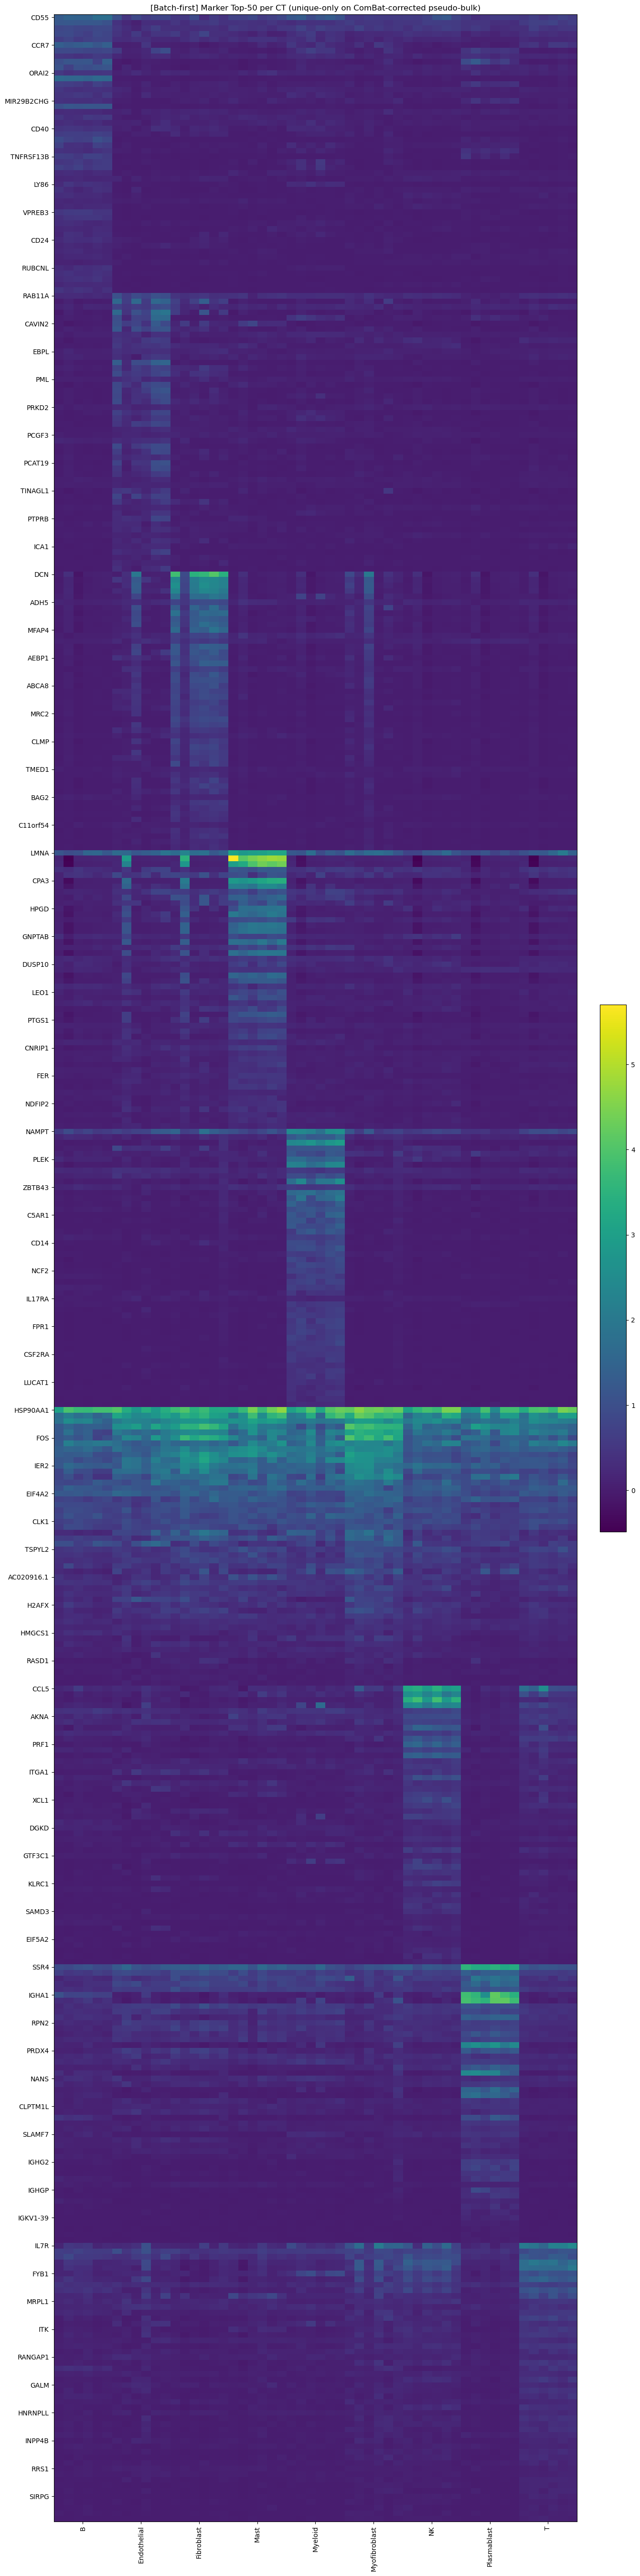

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 0 genes
  - B: kept 50 genes
  - Endothelial: kept 50 genes
  - Fibroblast: kept 50 genes
  - Mast: kept 50 genes
  - Myeloid: kept 50 genes
  - Myofibroblast: kept 50 genes
  - NK: kept 50 genes
  - Plasmablast: kept 50 genes
  - T: kept 50 genes
[Total rows plotted] 450


In [3]:

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(M.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


In [15]:
# --- Drop-in: batch-robust contrast score for marker picking on pseudo-bulk ---

import numpy as np
import pandas as pd

def contrast_score_batch_robust(pb: pd.DataFrame, ct: str) -> pd.Series:
    """
    批次魯棒版對比分數：
    1) 對每個 sample，將該 sample 內所有 CT 欄在「每個基因」上做中心化（減去該 sample 對應列的均值）
       => 移除 sample-level shift（批次偏移），保留 CT 間相對差異。
    2) 在中心化後矩陣上，計算 mean_ct - mean_rest（或 logFC；這裡用差值更穩）。
    只用於「選 marker」，不要把這個中心化後的矩陣拿去建最終的 S。
    """
    # 1) 解析 sample 與 ct
    samples = [c.split("|",1)[0] for c in pb.columns]
    cts      = [c.split("|",1)[1] for c in pb.columns]
    df = pb.copy()

    # 2) 逐 sample 做「基因內中心化」
    for s in sorted(set(samples)):
        cols_s = [col for col in pb.columns if col.startswith(s + "|")]
        if len(cols_s) <= 1:
            continue
        block = df[cols_s]                        # G × (#ct in this sample)
        centered = block.sub(block.mean(axis=1), axis=0)
        df[cols_s] = centered

    # 3) 在中心化矩陣上算對比分數（該 CT vs rest）
    cols_ct = [col for col in df.columns if col.endswith("|" + ct)]
    if len(cols_ct) == 0:
        return pd.Series(0.0, index=df.index)
    mean_ct   = df[cols_ct].mean(axis=1)
    other_cols= [c for c in df.columns if c not in cols_ct]
    mean_rest = df[other_cols].mean(axis=1) if other_cols else pd.Series(0.0, index=df.index)
    score = (mean_ct - mean_rest)  # 也可改成 np.log2((mean_ct+1e-9)/(mean_rest+1e-9))
    return score
